Import necessary libraries and define the main comparison function for temperature data analysis.

In [3]:
#%%
"""
Compare measured temperatures with COMSOL temperatures.
"""

import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

global_column_mapping = {}
air_column_mapping = {}

# Edit names in one place:
CANONICAL_AIR_MID_WALL = '315 <Air ambient mid side towards wall> (C)'

# Any incoming aliases are normalized to the canonical name above.
COLUMN_ALIASES = {
    '315 <Air ambient close to the wall> (C)': CANONICAL_AIR_MID_WALL,
    '102 <Air mid opposite side of 309> (C)': CANONICAL_AIR_MID_WALL,
}

MEASUREMENT_COLUMNS = [
    '103 <Air left> (C)',
    '301 <Air roof> (C)',
    '303 <Conductor BR mid> (C)',
    '304 <Jacket BR mid> (C)',
    '305 <Air BR mid> (C)',
    '307 <Condcutor BL mid> (C)',
    '308 <Jacket BL mid> (C)',
    '309 <Air BL mid> (C)',
    '310 <Condcutor TL mid> (C)',
    '311 <Jacket TL mid> (C)',
    '312 <Air TL mid> (C)',
    '313 <Top of multiduct inside material> (C)',
    '314 <Air ambient> (C)',
    CANONICAL_AIR_MID_WALL,
]

AIR_PLOT_COLUMNS = [
    '103 <Air left> (C)',
    '301 <Air roof> (C)',
    '314 <Air ambient> (C)',
    CANONICAL_AIR_MID_WALL,
]

# Master naming dictionary: edit labels for all channels here.
COLUMN_DISPLAY_NAMES = {
    '303 <Conductor BR mid> (C)': 'Conductor BR mid',
    '304 <Jacket BR mid> (C)': 'Jacket BR mid',
    '305 <Air BR mid> (C)': 'Air BR mid',
    '307 <Condcutor BL mid> (C)': 'Condcutor BL mid',
    '308 <Jacket BL mid> (C)': 'Jacket BL mid',
    '309 <Air BL mid> (C)': 'Air BL mid',
    '310 <Condcutor TL mid> (C)': 'Condcutor TL mid',
    '311 <Jacket TL mid> (C)': 'Jacket TL mid',
    '312 <Air TL mid> (C)': 'Air TL mid',
    '313 <Top of multiduct inside material> (C)': 'Top of multiduct inside material',
    '314 <Air ambient> (C)': 'Air ambient',
    '301 <Air roof> (C)': 'Air roof',
    '103 <Air left> (C)': 'Air left',
    '103 <Air right> (C)': 'Air right',
    CANONICAL_AIR_MID_WALL: 'Air ambient mid side towards wall',
    '102 <Conductor top left side> (C)': 'Conductor TL left ',
    '202 <Conductor top right side> (C)': 'Conductor TL right ',
    '101 <Jacket top left side> (C)': 'Jacket TL left ',
    '201 <Jacket top right side> (C)': 'Jacket TL right ',
}

AIR_DISPLAY_NAMES = {
    '314 <Air ambient> (C)': f"11 {COLUMN_DISPLAY_NAMES.get('314 <Air ambient> (C)', 'Air ambient')}" ,
    '301 <Air roof> (C)': f"12 {COLUMN_DISPLAY_NAMES.get('301 <Air roof> (C)', 'Air roof')}" ,
    CANONICAL_AIR_MID_WALL: f"13 {COLUMN_DISPLAY_NAMES.get(CANONICAL_AIR_MID_WALL, 'Air ambient mid side towards wall')}" ,
    '102 <Air mid opposite side of 309> (C)': f"13 {COLUMN_DISPLAY_NAMES.get(CANONICAL_AIR_MID_WALL, 'Air ambient mid side towards wall')}" ,
    '103 <Air left> (C)': f"14 {COLUMN_DISPLAY_NAMES.get('103 <Air left> (C)', 'Air left')}" ,
    '101 <Air left> (C)': f"14 {COLUMN_DISPLAY_NAMES.get('103 <Air left> (C)', 'Air left')}" ,
    '103 <Air right> (C)': f"15 {COLUMN_DISPLAY_NAMES.get('103 <Air right> (C)', 'Air right')}" ,
}

def spread_labels(y_values, min_gap=1.25):
    """
    Adjust y-positions so labels do not overlap.


    Parameters
    ----------
    y_values : array-like
        Original y-values for the labels.
    min_gap : float
        Minimum vertical spacing between labels.


    Returns
    -------
    adjusted : np.ndarray
        Adjusted y-positions.
    """
    y_values = np.array(y_values, dtype=float)
    n = len(y_values)
    if n == 0:
        return y_values

    adjusted = y_values.copy()
    order = np.argsort(adjusted)

    for _ in range(300):
        moved = False
        for i in range(1, n):
            prev_idx = order[i - 1]
            curr_idx = order[i]

            gap = adjusted[curr_idx] - adjusted[prev_idx]
            if gap < min_gap:
                mid = (adjusted[prev_idx] + adjusted[curr_idx]) / 2
                adjusted[prev_idx] = mid - min_gap / 2
                adjusted[curr_idx] = mid + min_gap / 2
                moved = True

        if not moved:
            break

    return adjusted


def compare_measured_and_comsol(
    meas_file,
    comsol_file,
    measurement_uncertainty=2.5,
    min_label_gap=2.0,
    title="Temperature",
    plot_measurements=False
    ):
    """
    Compare measured temperatures with COMSOL temperatures.


    Parameters
    ----------
    meas_file : str
        Path to measured CSV file.
    comsol_file : str
        Path to COMSOL CSV file.
    measurement_uncertainty : float, optional
        Uncertainty in measured values [Â°C]. Default is Â±2.5 Â°C.
    min_label_gap : float, optional
        Minimum vertical spacing between plot labels.
    title : str, optional
        Title for the measurement plot.
    plot_measurements : bool, optional
        If True, create the raw measurement plot during data loading.


    Returns
    -------
    df : pandas.DataFrame
        Cleaned measurement dataframe.
    df_last60_avg : pandas.DataFrame
        Average of the last 60 measured values.
    df_60_before : pandas.DataFrame
        Measured values 60 samples before the end.
    df_meas_comsol : pandas.DataFrame
        COMSOL temperatures with mapped column names.
    df_diff : pandas.DataFrame
        Comparison dataframe.
    df_diff_T : pandas.DataFrame
        Transposed comparison dataframe.
    avg_ambient : float
        Average ambient temperature over last 240 samples.
    """

    column_mapping = {
        "Temperature (degC), Point: 37": "307 <Condcutor BL mid> (C)",
        "307 Temperature (degC) BL cond": "307 <Condcutor BL mid> (C)",
        "Temperature (degC), Point: 43": "308 <Jacket BL mid> (C)",
        "308 Temperature (degC) BL jacket": "308 <Jacket BL mid> (C)",
        "Temperature (degC), Point: 44": "309 <Air BL mid> (C)",
        "309 Temperature (degC) BL air": "309 <Air BL mid> (C)",
        "Temperature (degC), Point: 52": "310 <Condcutor TL mid> (C)",
        "310 Temperature (degC) TL cond": "310 <Condcutor TL mid> (C)",
        "Temperature (degC), Point: 58": "311 <Jacket TL mid> (C)",
        "311 Temperature (degC) TL jacket": "311 <Jacket TL mid> (C)",
        "Temperature (degC), Point: 59": "312 <Air TL mid> (C)",
        "312 Temperature (degC) TL air": "312 <Air TL mid> (C)",
        "Temperature (degC), Point: 106": "303 <Conductor BR mid> (C)",
        "303 Temperature (degC) BR cond": "303 <Conductor BR mid> (C)",
        "Temperature (degC), Point: 112": "304 <Jacket BR mid> (C)",
        "304 Temperature (degC) BR jacket": "304 <Jacket BR mid> (C)",
        "Temperature (degC), Point: 113": "305 <Air BR mid> (C)",
        "305 Temperature (degC) BR air": "305 <Air BR mid> (C)",
        "Temperature (degC), Point: 1": "103 <Air left> (C)",
        "103 Temperature (degC) air left": "103 <Air left> (C)",
        "Temperature (degC), Point: 2": "301 <Air roof> (C)",
        "301 Temperature (degC) air roof": "301 <Air roof> (C)",
        "Temperature (degC), Point: 3": CANONICAL_AIR_MID_WALL,
        "315 Temperature (degC) air ambient mid": CANONICAL_AIR_MID_WALL
    }

    measurement_cols = MEASUREMENT_COLUMNS + list(COLUMN_ALIASES.keys())

    # -------------------------------------------------------------------------
    # Read measurement data
    # -------------------------------------------------------------------------
    df_raw = pd.read_csv(
        meas_file,
        encoding='utf-16',
        sep=',',
        skiprows=26
    )

    df = df_raw[[col for col in measurement_cols if col in df_raw.columns]]
    df = df.rename(columns=COLUMN_ALIASES)

    # -------------------------------------------------------------------------
    # Optional overview plot of measurement data
    # -------------------------------------------------------------------------
    if plot_measurements:
        plt.figure(figsize=(12, 6))
        max_value = df.max().max()
        cols = list(df.columns)

        for col in cols:
            plt.plot(df.index, df[col], label=col)

        last_idx = df.index[-1]
        label_x_offset = 12
        right_grid_padding = 60
        last_values = [df[col].iloc[-1] for col in cols]
        adjusted_last_y = spread_labels(last_values, min_gap=min_label_gap)

        for col, y_point, y_text in zip(cols, last_values, adjusted_last_y):
            plt.plot(last_idx, y_point, marker='o', markersize=8, color='black')
            plt.annotate(
                f"{y_point:.1f} °C",
                xy=(last_idx, y_point),
                xytext=(last_idx + label_x_offset, y_text),
                textcoords='data',
                fontsize=10,
                ha='left',
                va='center',
                arrowprops=dict(arrowstyle='-', color='black', lw=1)
            )

        plt.xlabel("Time [minutes]")
        plt.ylabel("Temperature [°C]")
        plt.title(title)
        plt.ylim(15, max(max_value + 5, max(adjusted_last_y) + 2))
        plt.xlim(df.index.min(), df.index.max() + right_grid_padding)
        plt.xticks(np.arange(df.index.min(), df.index.max() + right_grid_padding + 1, 60))
        plt.grid(True)
        plt.legend(loc="best", fontsize=8)
        plt.tight_layout()

        if title == "Temperature 520 A":
            col = "304 <Jacket BR mid> (C)"
            if col in df.columns:
                max_idx = df[col].idxmax()
                max_val = df[col].max()
                plt.plot(max_idx, max_val, marker='x', markersize=10, color='black')
                plt.annotate(
                    f"{max_val:.1f} °C",
                    xy=(max_idx, max_val),
                    xytext=(max_idx, max_val - 5),
                    textcoords='data',
                    fontsize=10,
                    ha='center',
                    va='top',
                    arrowprops=dict(arrowstyle='-', color='black', lw=1)
                )
        plt.show()

    # -------------------------------------------------------------------------
    # Average ambient temperature over last 240 samples
    # -------------------------------------------------------------------------
    avg_ambient = None
    ambient_col = '314 <Air ambient> (C)'

    if ambient_col in df_raw.columns:
        avg_ambient = df_raw[ambient_col].iloc[-240:].mean()

    # -------------------------------------------------------------------------
    # Average of last 60 samples
    # -------------------------------------------------------------------------
    df_last60_avg = pd.DataFrame(
        [df.iloc[-60:].mean()],
        index=['Measured_avg_last_60']
    )

    df_60_before = pd.DataFrame(
        [df.iloc[-61]],
        index=['Measured_60_before_end']
    )

    # -------------------------------------------------------------------------
    # Read COMSOL data
    # -------------------------------------------------------------------------
    with open(comsol_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    header_line = lines[4].lstrip('%').strip()
    data_line = lines[5].strip()

    headers = next(csv.reader([header_line]))
    values = [float(v) for v in next(csv.reader([data_line]))]

    df_meas_comsol = pd.DataFrame([values], columns=headers)
    df_meas_comsol = df_meas_comsol.rename(columns=column_mapping)
    df_meas_comsol.index = ['COMSOL']

    # -------------------------------------------------------------------------
    # Keep only common columns
    # -------------------------------------------------------------------------
    common_cols = df_last60_avg.columns.intersection(df_meas_comsol.columns)

    df_diff = pd.concat(
        [
            df_last60_avg[common_cols],
            df_meas_comsol[common_cols]
        ],
        axis=0
    )

    df_diff.index = ['Measured_avg_last_60', 'COMSOL']

    df_diff.loc['Measured_lower'] = (
        df_diff.loc['Measured_avg_last_60'] - measurement_uncertainty
    )

    df_diff.loc['Measured_upper'] = (
        df_diff.loc['Measured_avg_last_60'] + measurement_uncertainty
    )

    df_diff.loc['Difference'] = (
        df_diff.loc['Measured_avg_last_60'] - df_diff.loc['COMSOL']
    )

    df_diff = df_diff.loc[
        [
            'Measured_avg_last_60',
            'Measured_lower',
            'Measured_upper',
            'COMSOL',
            'Difference'
        ]
    ]

    df_diff_T = df_diff.T

    # Round to 1 decimal place for better readability
    df_last60_avg = df_last60_avg.round(1)
    df_60_before = df_60_before.round(1)
    df_meas_comsol = df_meas_comsol.round(1)
    df_diff = df_diff.round(1)
    df_diff_T = df_diff_T.round(1)
    if avg_ambient is not None:
        avg_ambient = round(avg_ambient, 1)

    return (
        df,
        df_last60_avg,
        df_60_before,
        df_meas_comsol,
        df_diff,
        df_diff_T,
        avg_ambient
    )




In [ ]:
def plot_temperature_data(df, title, min_label_gap=2.0):
    """
    Plot temperature data with standardized formatting and legend names.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing temperature data.
    title : str
        Title for the plot.
    min_label_gap : float, optional
        Minimum vertical spacing between end labels.
    """
    excluded_columns = {
        '103 <Air left> (C)',
        '301 <Air roof> (C)',
        CANONICAL_AIR_MID_WALL,
    }

    df_plot = df[[col for col in df.columns if col not in excluded_columns]]

    plt.figure(figsize=(12, 6))
    max_value = df_plot.max().max()
    cols = list(df_plot.columns)
    
    cols_sorted = sorted(cols, key=lambda col: int(global_column_mapping[col].split()[0]))
    
    for col in cols_sorted:
        label = global_column_mapping.get(col, col)
        num = int(label.split()[0])
        
        if 1 <= num <= 3:
            color = 'blue'
            if num == 1:
                linewidth = 3
                linestyle = '-'
            elif num == 2:
                linewidth = 1
                linestyle = '-'
            else:
                linewidth = 1
                linestyle = '--'
        elif 4 <= num <= 6:
            color = 'green'
            if num == 4:
                linewidth = 3
                linestyle = '-'
            elif num == 5:
                linewidth = 1
                linestyle = '-'
            else:
                linewidth = 1
                linestyle = '--'
        elif 7 <= num <= 9:
            color = 'red'
            if num == 7:
                linewidth = 3
                linestyle = '-'
            elif num == 8:
                linewidth = 1
                linestyle = '-'
            else:
                linewidth = 1
                linestyle = '--'
        else:
            linewidth = 2
            linestyle = '-'
            if num == 10:
                color = 'orange'
            else:
                color = 'purple'
        
        plt.plot(df_plot.index, df_plot[col], label=label, color=color, linewidth=linewidth, linestyle=linestyle)
    
    last_idx = df_plot.index[-1]
    label_x_offset = 12
    right_grid_padding = 60
    last_values = [df_plot[col].iloc[-1] for col in cols_sorted]
    adjusted_last_y = spread_labels(last_values, min_gap=min_label_gap)
    
    for col, y_point, y_text in zip(cols_sorted, last_values, adjusted_last_y):
        plt.plot(last_idx, y_point, marker='o', markersize=5, color='black')
        plt.annotate(
            f"{y_point:.1f} °C",
            xy=(last_idx, y_point),
            xytext=(last_idx + label_x_offset, y_text),
            textcoords='data',
            fontsize=10,
            ha='left',
            va='center',
            arrowprops=dict(arrowstyle='-', color='black', lw=1)
        )
    
    plt.xlabel("Time [min]")
    plt.ylabel("Temperature [°C]")
    plt.title(title)
    plt.ylim(15, max(max_value + 5, max(adjusted_last_y) + 2))
    plt.xlim(df_plot.index.min(), df_plot.index.max() + right_grid_padding)
    plt.xticks(np.arange(df_plot.index.min(), df_plot.index.max() + right_grid_padding + 1, 60))
    plt.grid(True)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=8)
    plt.tight_layout()
    
    if "520" in title:
        col = "304 <Jacket BR mid> (C)"
        if col in df_plot.columns:
            max_idx = df_plot[col].idxmax()
            max_val = df_plot[col].max()
            plt.plot(max_idx, max_val, marker='x', markersize=5, color='black')
            plt.annotate(
                f"{max_val:.1f} °C",
                xy=(max_idx, max_val),
                xytext=(max_idx, max_val - 5),
                textcoords='data',
                fontsize=10,
                ha='center',
                va='top',
                arrowprops=dict(arrowstyle='-', color='black', lw=1)
            )
    
    plt.show()


def plot_air_temperature_data(df, columns, title):
    plt.figure(figsize=(12, 6))
    cols_sorted = sorted(columns, key=lambda col: int(air_column_mapping[col].split()[0]))
    max_value = df[cols_sorted].max().max()

    for col in cols_sorted:
        label = air_column_mapping[col]
        color = None
        if label.startswith('11 Air ambient'):
            color = 'purple'
        elif 'Air left' in label:
            color = 'red'
        elif 'Air ambient mid side' in label:
            color = 'green'
        elif 'Air roof' in label:
            color = 'blue'
        elif 'Air right' in label:
            color = 'orange'

        plt.plot(df.index, df[col], label=label, color=color)

    last_idx = df.index[-1]
    label_x_offset = 12
    right_grid_padding = 60
    last_values = [df[col].iloc[-1] for col in cols_sorted]
    adjusted_last_y = spread_labels(last_values, min_gap=0.6)

    for col, y_point, y_text in zip(cols_sorted, last_values, adjusted_last_y):
        plt.plot(last_idx, y_point, marker='o', markersize=5, color='black')
        plt.annotate(
            f"{y_point:.1f} °C",
            xy=(last_idx, y_point),
            xytext=(last_idx + label_x_offset, y_text),
            textcoords='data',
            fontsize=10,
            ha='left',
            va='center',
            arrowprops=dict(arrowstyle='-', color='black', lw=1)
        )

    plt.xlabel('Time [min]')
    plt.ylabel('Temperature [°C]')
    plt.title(title)
    plt.ylim(15, max(max_value + 2.5, max(adjusted_last_y) + 2))
    plt.xlim(df.index.min(), df.index.max() + right_grid_padding)
    plt.xticks(np.arange(df.index.min(), df.index.max() + right_grid_padding + 1, 60))
    plt.grid(True)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
# Load and process 520A data
df_520, df_last60_avg_520, df_60_before_520, df_meas_comsol_520, df_diff_520, df_diff_T_520, avg_ambient_520 = compare_measured_and_comsol(
    meas_file="520 A black tape on jacket conductor good setup.csv",
    comsol_file="520A temp from comsol.csv",
    title="Temperature 520 A"
)

In [ ]:
# Load and process 420A data
df_420, df_last60_avg_420, df_60_before_420, df_meas_comsol_420, df_diff_420, df_diff_T_420, avg_ambient_420 = compare_measured_and_comsol(
    meas_file="420 A black tape on jacket conductor at ends not properly drilled into.csv",
    comsol_file="420A temp from comsol.csv",
    title="Temperature 420 A"
)

In [ ]:
# Load and process 300A data
df_300, df_last60_avg_300, df_60_before_300, df_meas_comsol_300, df_diff_300, df_diff_T_300, avg_ambient_300 = compare_measured_and_comsol(
    meas_file="300 A black tape on jacket conductor good setup.csv",
    comsol_file="300A temp from comsol.csv",
    title="Temperature 300 A"
)

In [4]:
# Create a global mapping dictionary with the new naming convention based on 520A ordering
# This mapping will be used consistently across all plots and tables

excluded_columns = {
    '103 <Air left> (C)',
    '301 <Air roof> (C)',
    CANONICAL_AIR_MID_WALL,
}

# Get the column order based on 520A values (sorted descending)
temp_series = df_520.iloc[-1].sort_values(ascending=False)
ordered_columns = [col for col in temp_series.index.tolist() if col not in excluded_columns]

# Create the new naming convention: number + descriptive text (no (C))
global_column_mapping = {}
for i, col in enumerate(ordered_columns):
    descriptive_part = COLUMN_DISPLAY_NAMES.get(col)
    if descriptive_part is None:
        clean_name = col.replace('<', '').replace('>', '').replace('(C)', '').strip()
        parts = clean_name.split(' ', 1)
        if len(parts) > 1:
            descriptive_part = parts[1]
        else:
            descriptive_part = clean_name
    
    new_name = f"{i+1} {descriptive_part}"
    global_column_mapping[col] = new_name

air_column_mapping = AIR_DISPLAY_NAMES.copy()

print("Global column mapping (old name -> new name):")
for old, new in global_column_mapping.items():
    print(f"  {old} -> {new}")

NameError: name 'df_520' is not defined

In [ ]:
# Create a dataframe with final temperatures (last recorded sample) for 300A, 420A, and 520A
final_temps = pd.DataFrame({
    '520A': df_520.iloc[-1],
    '420A': df_420.iloc[-1],
    '300A': df_300.iloc[-1]
})

# Keep only the columns that are part of the renaming logic
final_temps = final_temps.loc[ordered_columns]

# Sort rows based on 520A values from high to low
final_temps = final_temps.sort_values(by='520A', ascending=False)

# Apply the global column mapping to the index
final_temps.index = [global_column_mapping[col] for col in final_temps.index]

print("Final temperatures (last recorded value) for 300A, 420A, and 520A, sorted by 520A values descending:")
print(final_temps)

# Verify the order is the same for 420A and 300A
sorted_420 = final_temps.sort_values(by='420A', ascending=False).index
sorted_300 = final_temps.sort_values(by='300A', ascending=False).index

print("\nOrder by 520A (current):", final_temps.index.tolist())
print("Order by 420A:", sorted_420.tolist())
print("Order by 300A:", sorted_300.tolist())

print("\nSame order for 420A as 520A?", sorted_420.equals(final_temps.index))
print("Same order for 300A as 520A?", sorted_300.equals(final_temps.index))

Final temperatures (last recorded value) for 300A, 420A, and 520A, sorted by 520A values descending:
                                       520A    420A    300A
1 Condcutor TL mid                   89.718  66.786  44.691
2 Condcutor BL mid                   86.120  64.292  43.385
3 Conductor BR mid                   81.968  62.450  42.223
4 Jacket TL mid                      71.729  55.971  39.203
5 Jacket BL mid                      70.803  55.148  38.535
6 Jacket BR mid                      64.613  52.202  36.767
7 Air BL mid                         48.888  42.688  30.789
8 Air BR mid                         46.101  38.029  29.995
9 Air TL mid                         45.198  39.200  29.531
10 Top of multiduct inside material  35.615  32.088  26.419
11 Air ambient                       22.578  22.480  21.838

Order by 520A (current): ['1 Condcutor TL mid', '2 Condcutor BL mid', '3 Conductor BR mid', '4 Jacket TL mid', '5 Jacket BL mid', '6 Jacket BR mid', '7 Air BL mid', '8 Air BR mid

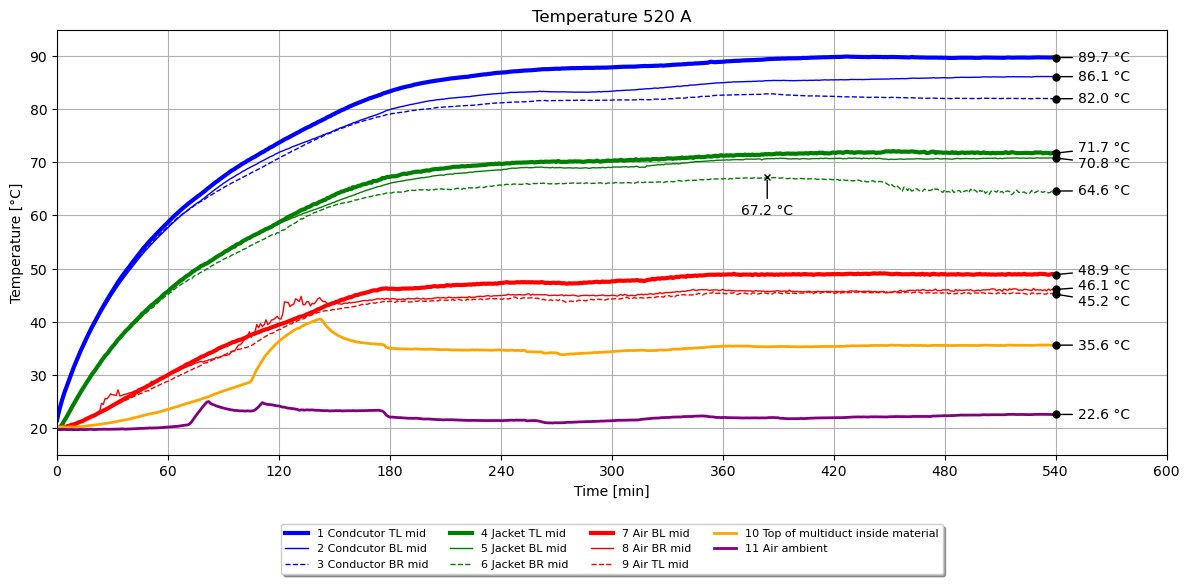

In [ ]:
# Plot 520 A with new legend names using global column mapping
plot_temperature_data(df_520, "Temperature 520 A", min_label_gap=3.0)

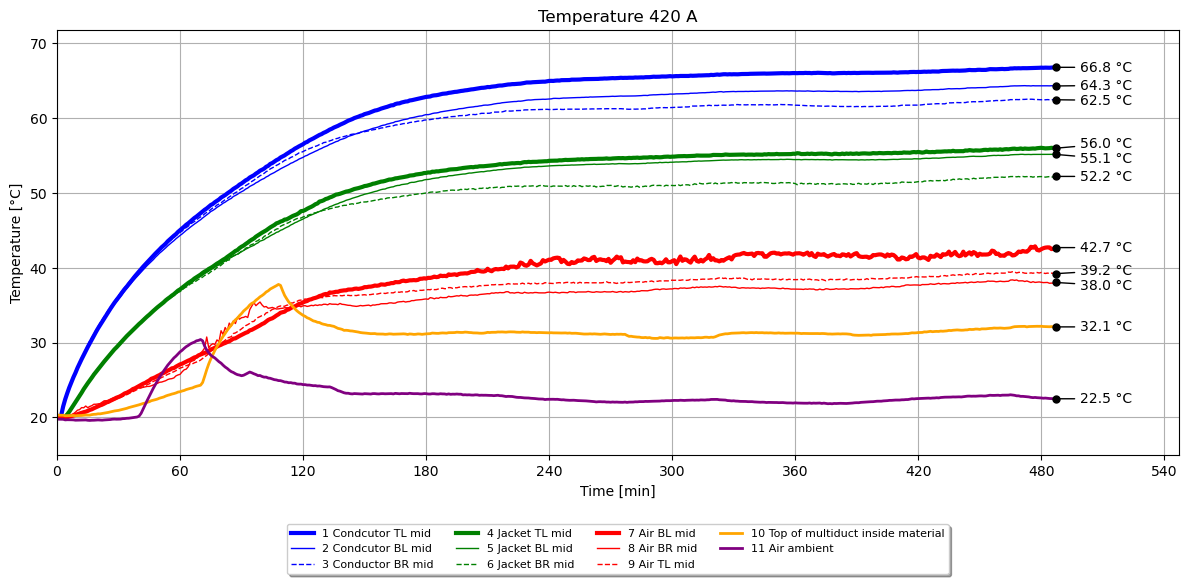

In [ ]:
# Plot 420 A with new legend names using global column mapping
plot_temperature_data(df_420, "Temperature 420 A", min_label_gap=2)

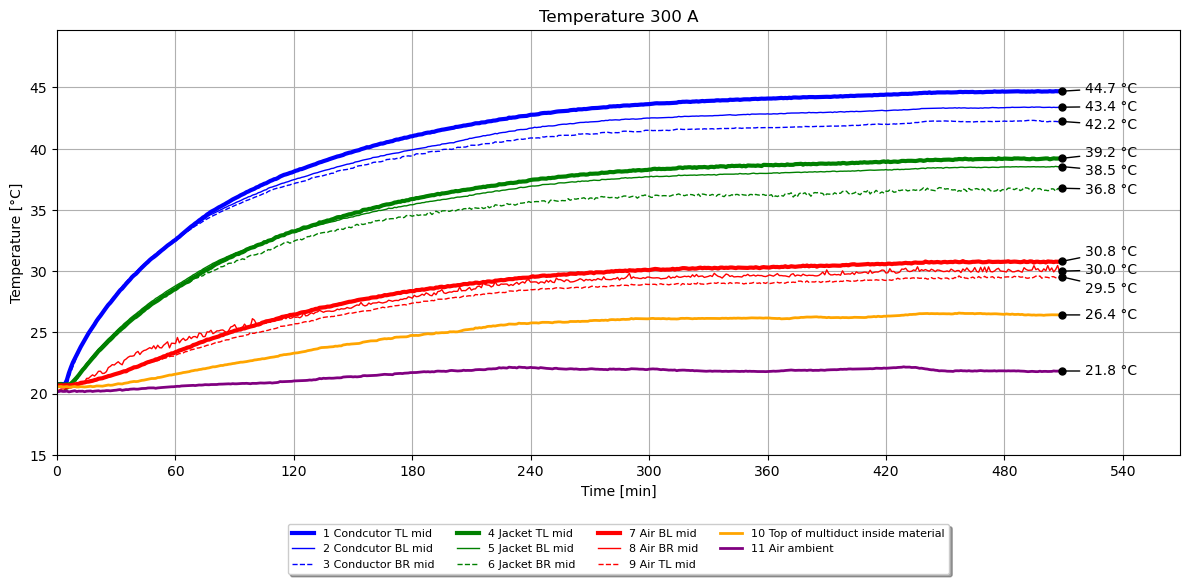

In [ ]:
# Plot 300 A with new legend names using global column mapping
plot_temperature_data(df_300, "Temperature 300 A", min_label_gap=1.5)

In [ ]:
# Find largest difference between last and -60 for 520 A (excluding 7,8,9)
cols = ordered_columns
differences_520 = {}
for col in cols:
    label = global_column_mapping[col]
    num = int(label.split()[0])
    
    if num not in [7, 8, 9]:
        diff = df_520[col].iloc[-1] - df_520[col].iloc[-60]
        differences_520[col] = diff

max_col_520 = max(differences_520, key=differences_520.get)
max_diff_520 = differences_520[max_col_520]
max_name_520 = global_column_mapping[max_col_520]

print("520 A - Largest difference between last and -60 samples (excluding 7,8,9):")
print(f"  {max_name_520}: {max_diff_520:.2f} °C")
print(f"  Value at -60: {df_520[max_col_520].iloc[-60]:.2f} °C")
print(f"  Value at -1: {df_520[max_col_520].iloc[-1]:.2f} °C")

520 A - Largest difference between last and -60 samples (excluding 7,8,9):
  11 Air ambient: 0.25 °C
  Value at -60: 22.33 °C
  Value at -1: 22.58 °C


In [ ]:
# Find largest difference between last and -60 for 420 A (excluding 7,8,9)
cols = ordered_columns
differences_420 = {}

for col in cols:
    if col not in df_420.columns:
        continue

    label = global_column_mapping[col]
    num = int(label.split()[0])
    
    if num not in [7, 8, 9]:
        diff = df_420[col].iloc[-1] - df_420[col].iloc[-60]
        differences_420[col] = diff

max_col_420 = max(differences_420, key=differences_420.get)
max_diff_420 = differences_420[max_col_420]
max_name_420 = global_column_mapping[max_col_420]

print("420 A - Largest difference between last and -60 samples (excluding 7,8,9):")
print(f"  {max_name_420}: {max_diff_420:.2f} °C")
print(f"  Value at -60: {df_420[max_col_420].iloc[-60]:.2f} °C")
print(f"  Value at -1: {df_420[max_col_420].iloc[-1]:.2f} °C")

420 A - Largest difference between last and -60 samples (excluding 7,8,9):
  10 Top of multiduct inside material: 0.62 °C
  Value at -60: 31.47 °C
  Value at -1: 32.09 °C


In [ ]:
# Find largest difference between last and -60 for 300 A (excluding 7,8,9)
cols = ordered_columns
differences_300 = {}

for col in cols:
    if col not in df_300.columns:
        continue

    label = global_column_mapping[col]
    num = int(label.split()[0])
    
    if num not in [7, 8, 9]:
        diff = df_300[col].iloc[-1] - df_300[col].iloc[-60]
        differences_300[col] = diff

max_col_300 = max(differences_300, key=differences_300.get)
max_diff_300 = differences_300[max_col_300]
max_name_300 = global_column_mapping[max_col_300]

print("300 A - Largest difference between last and -60 samples (excluding 7,8,9):")
print(f"  {max_name_300}: {max_diff_300:.2f} °C")
print(f"  Value at -60: {df_300[max_col_300].iloc[-60]:.2f} °C")
print(f"  Value at -1: {df_300[max_col_300].iloc[-1]:.2f} °C")

300 A - Largest difference between last and -60 samples (excluding 7,8,9):
  4 Jacket TL mid: 0.11 °C
  Value at -60: 39.10 °C
  Value at -1: 39.20 °C


In [ ]:
df_raw = pd.read_csv(
        r"520 A black tape on jacket conductor good setup.csv",
        encoding='utf-16',
        sep=',',
        skiprows=26
    )

df_raw.columns

Index(['Scan', 'Time', '101 <Jacket top left side> (C)',
       '102 <Conductor top left side> (C)', '103 <Air left> (C)',
       '201 <Jacket top right side> (C)', '202 <Conductor top right side> (C)',
       '301 <Air roof> (C)', '303 <Conductor BR mid> (C)',
       '304 <Jacket BR mid> (C)', '305 <Air BR mid> (C)',
       '307 <Condcutor BL mid> (C)', '308 <Jacket BL mid> (C)',
       '309 <Air BL mid> (C)', '310 <Condcutor TL mid> (C)',
       '311 <Jacket TL mid> (C)', '312 <Air TL mid> (C)',
       '313 <Top of multiduct inside material> (C)', '314 <Air ambient> (C)',
       '315 <Air ambient mid side towards wall> (C)'],
      dtype='object')

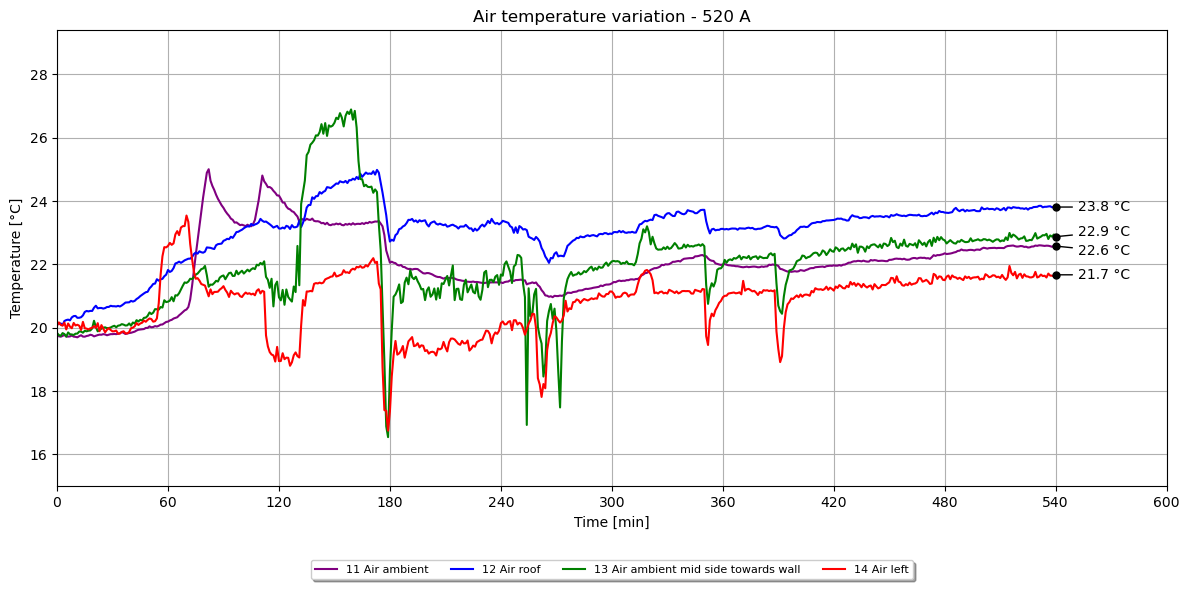

In [ ]:
# Apply centralized alias normalization and use shared air-plot columns.
df_520_for_air_plot = df_520.rename(columns=COLUMN_ALIASES)
air_columns_520 = AIR_PLOT_COLUMNS

air_df_520 = df_520_for_air_plot[air_columns_520]
plot_air_temperature_data(air_df_520, air_columns_520, 'Air temperature variation - 520 A')

In [6]:
df_raw_420 = pd.read_csv(
    r"420 A black tape on jacket conductor at ends not properly drilled into.csv",
    encoding='utf-16',
    sep=',',
    skiprows=26
)

air_columns_420 = [
    '101 <Air left> (C)',
    '102 <Air mid opposite side of 309> (C)',
    '103 <Air right> (C)',
    '314 <Air ambient> (C)',
]

air_df_420 = df_raw_420[air_columns_420]
plot_air_temperature_data(air_df_420, air_columns_420, 'Air temperature variation - 420 A')

NameError: name 'plot_air_temperature_data' is not defined

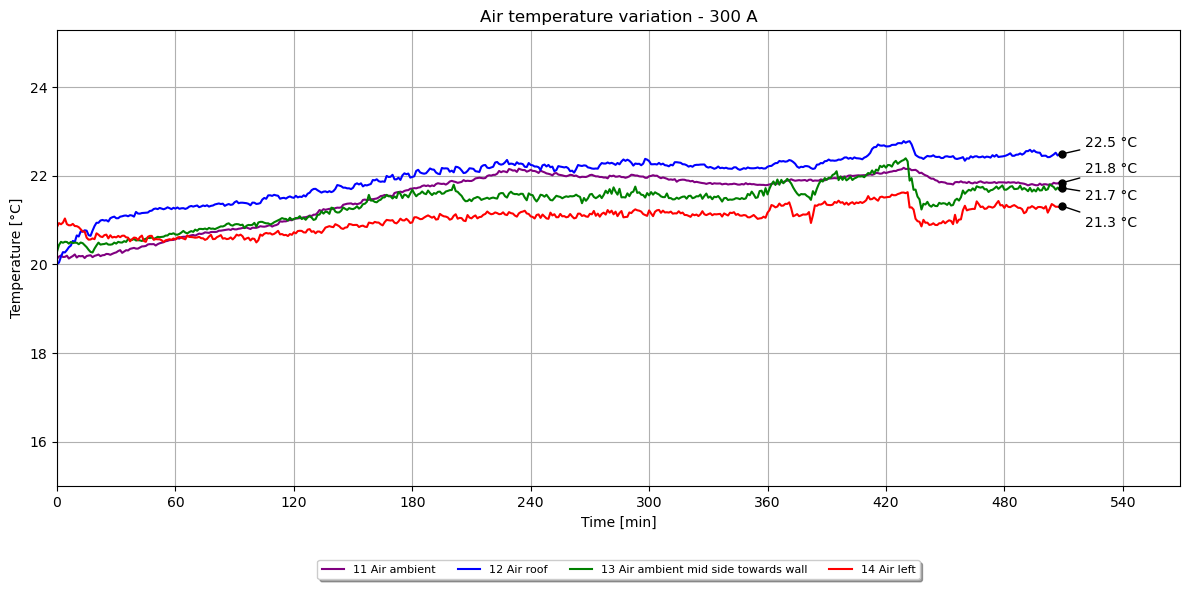

In [ ]:
air_columns_300 = [
    '103 <Air left> (C)',
    '301 <Air roof> (C)',
    '314 <Air ambient> (C)',
    '315 <Air ambient mid side towards wall> (C)',
]

air_df_300 = df_300[air_columns_300]
plot_air_temperature_data(air_df_300, air_columns_300, 'Air temperature variation - 300 A')

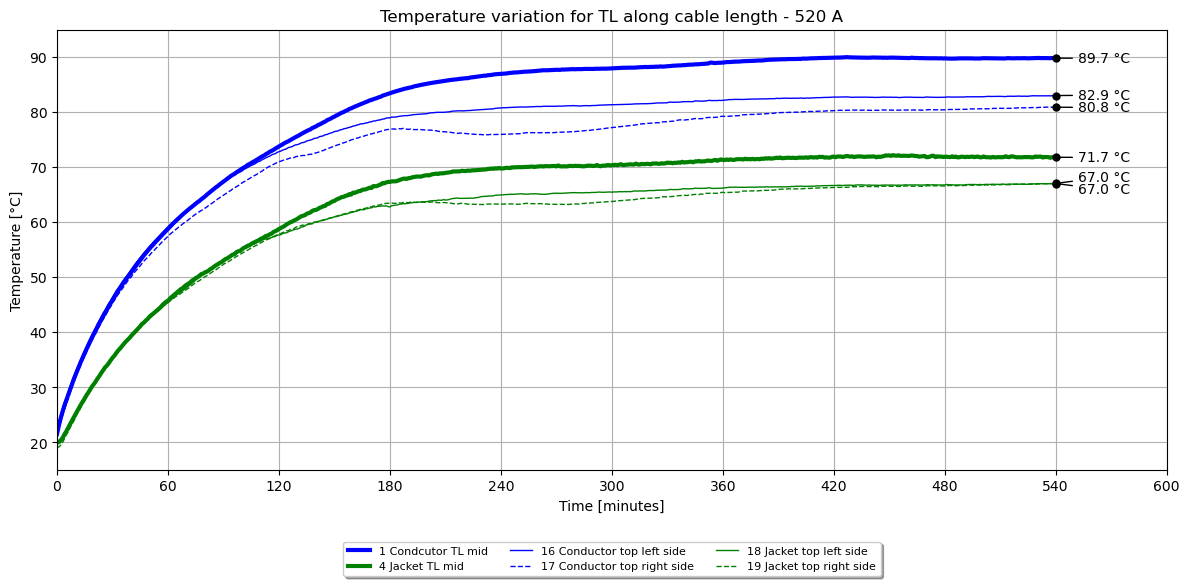

In [ ]:
extra_columns_520 = [
    '102 <Conductor top left side> (C)',
    '202 <Conductor top right side> (C)',
    '310 <Condcutor TL mid> (C)',
    '101 <Jacket top left side> (C)',
    '201 <Jacket top right side> (C)',
    '311 <Jacket TL mid> (C)',
]

extra_df_520 = df_raw[extra_columns_520]

extra_label_mapping_520 = {
    '310 <Condcutor TL mid> (C)': global_column_mapping['310 <Condcutor TL mid> (C)'],
    '311 <Jacket TL mid> (C)': global_column_mapping['311 <Jacket TL mid> (C)'],
}

remaining_extra_columns_520 = [
    col for col in extra_columns_520 if col not in extra_label_mapping_520
]
remaining_extra_last_values_520 = extra_df_520.iloc[-1][remaining_extra_columns_520].sort_values(ascending=False)

existing_numbers = [
    int(label.split()[0]) for label in list(global_column_mapping.values()) + list(air_column_mapping.values())
]
next_number = max(existing_numbers) + 1

for offset, col in enumerate(remaining_extra_last_values_520.index):
    clean_name = col.replace('<', '').replace('>', '').replace('(C)', '').strip()
    descriptive_part = clean_name.split(' ', 1)[1]
    extra_label_mapping_520[col] = f"{next_number + offset} {descriptive_part}"

extra_cols_sorted_520 = sorted(
    extra_columns_520,
    key=lambda col: int(extra_label_mapping_520[col].split()[0])
)

conductor_columns_520 = [
    '310 <Condcutor TL mid> (C)',
    '102 <Conductor top left side> (C)',
    '202 <Conductor top right side> (C)',
]
jacket_columns_520 = [
    '311 <Jacket TL mid> (C)',
    '101 <Jacket top left side> (C)',
    '201 <Jacket top right side> (C)',
]

style_by_rank = [
    {'linewidth': 3, 'linestyle': '-'},
    {'linewidth': 1, 'linestyle': '-'},
    {'linewidth': 1, 'linestyle': '--'},
]

line_styles_520 = {}
for rank, col in enumerate(conductor_columns_520):
    line_styles_520[col] = {'color': 'blue', **style_by_rank[rank]}
for rank, col in enumerate(jacket_columns_520):
    line_styles_520[col] = {'color': 'green', **style_by_rank[rank]}

plt.figure(figsize=(12, 6))
for col in extra_cols_sorted_520:
    plt.plot(
        extra_df_520.index,
        extra_df_520[col],
        label=extra_label_mapping_520[col],
        **line_styles_520[col]
    )

last_idx = extra_df_520.index[-1]
label_x_offset = 12
right_grid_padding = 60
last_values = [extra_df_520[col].iloc[-1] for col in extra_cols_sorted_520]
adjusted_last_y = spread_labels(last_values, min_gap=2.25)

for col, y_point, y_text in zip(extra_cols_sorted_520, last_values, adjusted_last_y):
    plt.plot(last_idx, y_point, marker='o', markersize=5, color='black')
    plt.annotate(
        f"{y_point:.1f} °C",
        xy=(last_idx, y_point),
        xytext=(last_idx + label_x_offset, y_text),
        textcoords='data',
        fontsize=10,
        ha='left',
        va='center',
        arrowprops=dict(arrowstyle='-', color='black', lw=1)
    )

plt.xlabel('Time [minutes]')

plt.ylabel('Temperature [°C]')
plt.title('Temperature variation for TL along cable length - 520 A')
plt.ylim(15, max(extra_df_520.max().max() + 5, max(adjusted_last_y) + 2))
plt.xlim(extra_df_520.index.min(), extra_df_520.index.max() + right_grid_padding)
plt.xticks(np.arange(extra_df_520.index.min(), extra_df_520.index.max() + right_grid_padding + 1, 60))
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

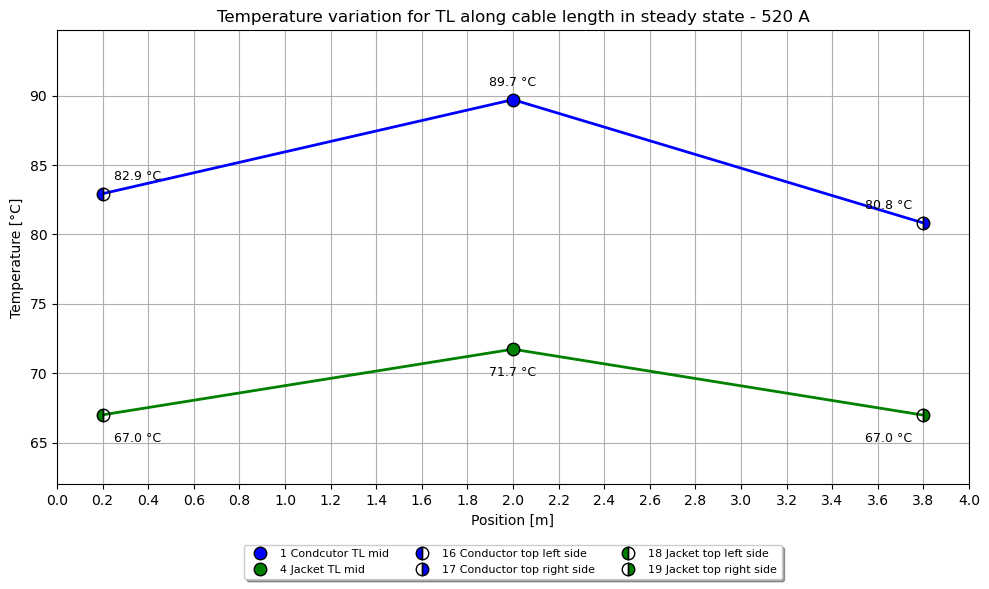

In [ ]:
position_map_520 = {
    '102 <Conductor top left side> (C)': 0.2,
    '101 <Jacket top left side> (C)': 0.2,
    '310 <Condcutor TL mid> (C)': 2.0,
    '311 <Jacket TL mid> (C)': 2.0,
    '202 <Conductor top right side> (C)': 3.8,
    '201 <Jacket top right side> (C)': 3.8,
}

conductor_position_columns_520 = [
    '102 <Conductor top left side> (C)',
    '310 <Condcutor TL mid> (C)',
    '202 <Conductor top right side> (C)',
]

jacket_position_columns_520 = [
    '101 <Jacket top left side> (C)',
    '311 <Jacket TL mid> (C)',
    '201 <Jacket top right side> (C)',
]

conductor_x_520 = [position_map_520[col] for col in conductor_position_columns_520]
conductor_y_520 = [df_raw[col].iloc[-1] for col in conductor_position_columns_520]
conductor_labels_520 = [extra_label_mapping_520[col] for col in conductor_position_columns_520]

jacket_x_520 = [position_map_520[col] for col in jacket_position_columns_520]
jacket_y_520 = [df_raw[col].iloc[-1] for col in jacket_position_columns_520]
jacket_labels_520 = [extra_label_mapping_520[col] for col in jacket_position_columns_520]

# Cleaner point style: same marker shape, but fill style distinguishes left/mid/right.
fillstyle_by_column_520 = {
    '102 <Conductor top left side> (C)': 'left',
    '101 <Jacket top left side> (C)': 'left',
    '310 <Condcutor TL mid> (C)': 'full',
    '311 <Jacket TL mid> (C)': 'full',
    '202 <Conductor top right side> (C)': 'right',
    '201 <Jacket top right side> (C)': 'right',
}

def annotation_style(x_pos, y_offset):
    if x_pos <= 0.4:
        return (8, y_offset), 'left'
    if x_pos >= 3.6:
        return (-8, y_offset), 'right'
    return (0, y_offset), 'center'


all_position_y_520 = conductor_y_520 + jacket_y_520
y_min_520 = min(all_position_y_520) - 5
y_max_520 = max(all_position_y_520) + 5

plt.figure(figsize=(10, 6))
plt.plot(
    conductor_x_520,
    conductor_y_520,
    color='blue',
    linewidth=2,
    label='_nolegend_'
)
plt.plot(
    jacket_x_520,
    jacket_y_520,
    color='green',
    linewidth=2,
    label='_nolegend_'
)

for col, x_pos, y_pos, label in zip(
    conductor_position_columns_520,
    conductor_x_520,
    conductor_y_520,
    conductor_labels_520
    ):
    plt.plot(
        x_pos,
        y_pos,
        marker='o',
        markersize=9,
        markerfacecolor='blue',
        markeredgecolor='black',
        markeredgewidth=1.0,
        fillstyle=fillstyle_by_column_520[col],
        linestyle='None',
        label=label
    )
    xytext, ha = annotation_style(x_pos, 8)
    plt.annotate(
        f"{y_pos:.1f} °C",
        xy=(x_pos, y_pos),
        xytext=xytext,
        textcoords='offset points',
        ha=ha,
        va='bottom',
        fontsize=9,
    )

for col, x_pos, y_pos, label in zip(
    jacket_position_columns_520,
    jacket_x_520,
    jacket_y_520,
    jacket_labels_520
    ):
    plt.plot(
        x_pos,
        y_pos,
        marker='o',
        markersize=9,
        markerfacecolor='green',
        markeredgecolor='black',
        markeredgewidth=1.0,
        fillstyle=fillstyle_by_column_520[col],
        linestyle='None',
        label=label
    )
    xytext, ha = annotation_style(x_pos, -12)
    plt.annotate(
        f"{y_pos:.1f} °C",
        xy=(x_pos, y_pos),
        xytext=xytext,
        textcoords='offset points',
        ha=ha,
        va='top',
        fontsize=9,
    )

plt.xlabel('Position [m]')
plt.ylabel('Temperature [°C]')
plt.title('Temperature variation for TL along cable length in steady state - 520 A')
plt.xlim(0, 4)
plt.ylim(y_min_520, y_max_520)
plt.xticks(np.arange(0, 4.1, 0.2))
plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
legend_items = []
for handle, label in zip(handles, labels):
    if label == '_nolegend_':
        continue
    try:
        label_number = int(label.split()[0])
    except (ValueError, IndexError):
        label_number = float('inf')
    legend_items.append((label_number, handle, label))

legend_items.sort(key=lambda item: item[0])
sorted_handles = [item[1] for item in legend_items]
sorted_labels = [item[2] for item in legend_items]

plt.legend(
    sorted_handles,
    sorted_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    fancybox=True,
    shadow=True,
    ncol=3,
    fontsize=8
)
plt.tight_layout()
plt.show()